# Part 0.1 — Stats 101

**Goal:** Summarize security data quickly and correctly (means, medians, quantiles, rates) and know when the "obvious" summary will mislead you.

## Why summary statistics matter for security decisions

Every security decision rests on a number somebody summarized. Alert volumes decide staffing levels. Mean-time-to-respond (MTTR) metrics appear in board decks. Breach-cost estimates feed risk registers. If the summary is wrong or if it uses the wrong measure then the decision it supports is wrong too.

Security data is rarely well-behaved. Response times are right-skewed, loss amounts span orders of magnitude, and click rates cluster near zero. The standard "take the average" reflex can be actively dangerous in these regimes. This notebook covers the summary statistics that actually matter when the data fights back, and highlights the moments you need something better.

None of this requires advanced statistics. But it does require discipline, picking the right summary for the shape of your data, attaching an uncertainty interval, and knowing which traps to avoid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from decision_security.synth import make_rng, sample

# Publication figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## Location: Mean vs Median

The mean and median both answer "what's typical?" but they disagree when the data is skewed.

The arithmetic mean $\bar x = \frac{1}{n}\sum x_i$ weights every observation equally, which makes it sensitive to outliers. Consider MTTR across incidents: most tickets close in 2--4 hours, but a handful of complex investigations run for weeks. The mean might report 18 hours while the median sits at 3.5 hours. A staffing model built on the mean over-provisions; an SLA built on it looks easy to hit until the next tail event.

The **median** is the middle value when you sort the data. Half the observations fall above it, half below. It ignores how extreme the extremes are — whether your worst incident took 200 hours or 2,000, the median doesn't move.

The **trimmed mean** — dropping the top and bottom $k$% before averaging — offers a middle ground. A 10% trimmed mean on MTTR discards the worst outliers while still reflecting more of the distribution than the median alone. It is a useful "robust average" for operational metrics where you want sensitivity to shifts in the bulk of the data without tail contamination.

In security, almost everything is right-skewed: most incidents resolve fast, but a few take orders of magnitude longer. Response times, dwell times, breach costs, vulnerability age — all follow this pattern (roughly lognormal). For these distributions:

- The **median** tells you the *typical experience* — what most incidents actually look like
- The **mean** tells you the *budget expectation* — what you'd spend per incident on average if you had to plan for the total

Use the **median** when the distribution is skewed or heavy-tailed — which in security means almost always. Use the **mean** when the distribution is roughly symmetric (rare) or when you genuinely need the total divided by count (e.g., average cost per user for budget allocation). A good habit: report both, plus the ratio. When mean/median > 2, you are deep in skew territory and the mean alone is misleading.

> **Note:** Lognormal data is the default in security operations. Response times, dwell times, and loss amounts all tend to follow roughly lognormal shapes. On lognormal data the median equals $e^{\mu}$ and is a far more stable summary than the mean.

In [2]:
response_hours = sample('lognormal', 500, meanlog=3.0, sdlog=1.5, rng=make_rng(42))

mean_val = np.mean(response_hours)
median_val = np.median(response_hours)

print(f"Mean response time:   {mean_val:.1f} hours")
print(f"Median response time: {median_val:.1f} hours")
print(f"\nThe mean is {mean_val / median_val:.1f}x the median — pulled by outliers.")

Mean response time:   57.3 hours
Median response time: 20.2 hours

The mean is 2.8x the median — pulled by outliers.


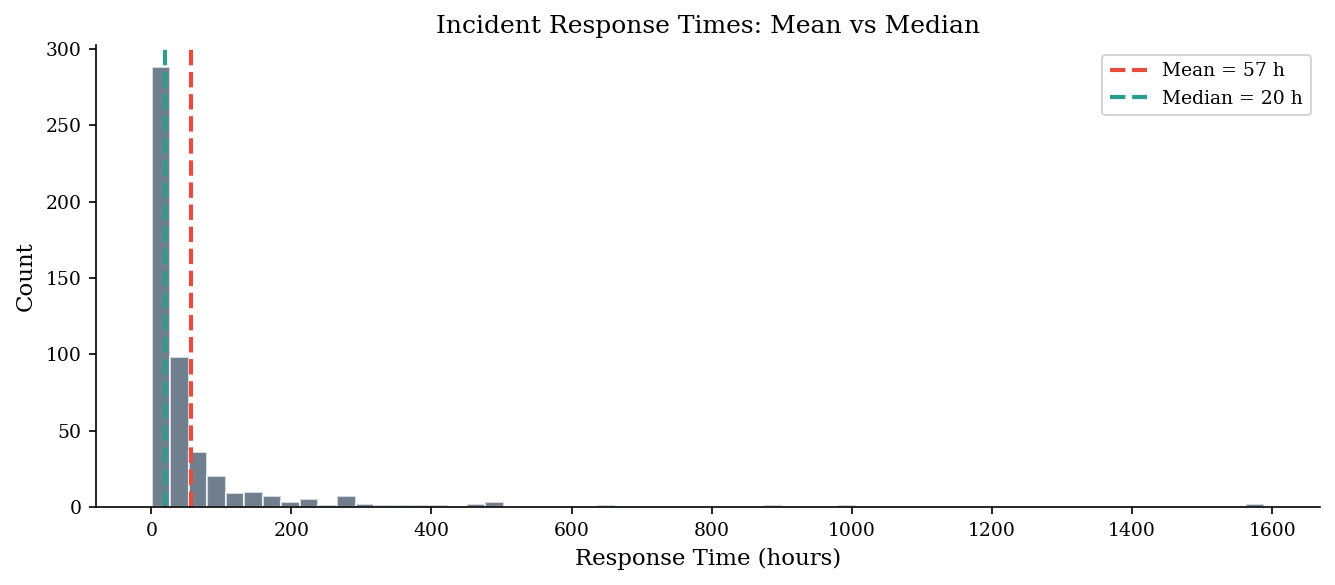

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(response_hours, bins=60, edgecolor="white", alpha=0.7, color=DARK_BG)
ax.axvline(mean_val, color=ACCENT, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.0f} h")
ax.axvline(median_val, color="#2a9d8f", linestyle="--", linewidth=2, label=f"Median = {median_val:.0f} h")
ax.set_xlabel("Response Time (hours)")
ax.set_ylabel("Count")
ax.set_title("Incident Response Times: Mean vs Median")
ax.legend()
plt.tight_layout()
plt.show()

## Spread: Variance, Standard Deviation, IQR

Knowing the center isn't enough — you need to also know how *wide* the data spreads.

Variance $s^2 = \frac{1}{n-1}\sum (x_i - \bar x)^2$ and its square root, the standard deviation, measure dispersion symmetrically around the mean. When the data is skewed, variance is inflated by the same tail observations that distort the mean. The **interquartile range** (IQR = $Q_{75} - Q_{25}$) is a robust alternative: it describes the spread of the middle 50% and is unaffected by extreme tails.

For security dashboards, pair the **median with the IQR** for a resilient center-and-spread summary. Reserve standard deviation for contexts where the data is approximately symmetric — for instance, login-attempt counts per hour during normal operations, which often approximate a Poisson or normal shape. If the std dev is larger than the median, that's a strong signal that the mean-based summary is misleading.

Another useful measure is the **coefficient of variation** (CV = $s / \bar x$), which expresses spread relative to the mean. A CV above 1 signals high relative variability — common for breach costs and dwell times. When comparing variability across metrics with different units or scales (e.g., MTTR in hours vs loss in dollars), the CV provides a unit-free comparison that standard deviation alone cannot.

> **Note:** The **median absolute deviation** (MAD) is another robust spread measure: $\text{MAD} = \text{median}(|x_i - \text{median}(x)|)$. Scaled by 1.4826, it estimates standard deviation under normality but resists outlier contamination. It is a good alternative to IQR when you want a single-number robust spread.

In [4]:
var_val = np.var(response_hours)
std_val = np.std(response_hours)
q25, q75 = np.percentile(response_hours, [25, 75])
iqr_val = q75 - q25

print(f"Variance:  {var_val:,.1f}")
print(f"Std Dev:   {std_val:,.1f}")
print(f"IQR:       {iqr_val:.1f}  (Q25={q25:.1f}, Q75={q75:.1f})")
print(f"\nStd dev ({std_val:.0f}) is larger than the median ({median_val:.0f}) — a sign the distribution is skewed.")
print(f"IQR ({iqr_val:.1f}) gives the range where the middle 50% of incidents land.")

Variance:  18,849.5
Std Dev:   137.3
IQR:       41.1  (Q25=7.4, Q75=48.5)

Std dev (137) is larger than the median (20) — a sign the distribution is skewed.
IQR (41.1) gives the range where the middle 50% of incidents land.


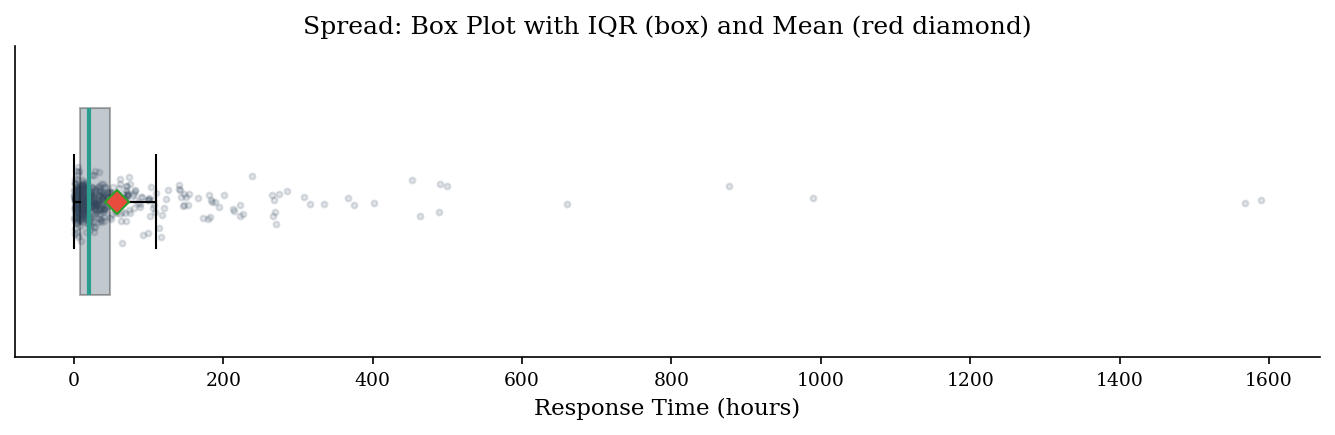

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
bp = ax.boxplot(response_hours, vert=False, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=DARK_BG, alpha=0.3),
                medianprops=dict(color="#2a9d8f", linewidth=2),
                meanprops=dict(marker="D", markerfacecolor=ACCENT, markersize=8),
                showmeans=True, showfliers=False)
ax.scatter(response_hours, np.random.normal(1, 0.04, len(response_hours)),
           alpha=0.15, s=8, color=DARK_BG)
ax.set_xlabel("Response Time (hours)")
ax.set_title("Spread: Box Plot with IQR (box) and Mean (red diamond)")
ax.set_yticks([])
plt.tight_layout()
plt.show()

## Quantiles as Guardrails

Quantiles answer "what value is exceeded only $p$% of the time?" The 95th percentile ($Q_{0.95}$) of incident response time tells you the threshold below which 95% of incidents resolve. This maps directly to SLA language, budget reserves, and staffing ceilings.

An average hides tail risk. "Average response is 20 hours" sounds fine, but if p95 is 223 hours, 1 in 20 incidents takes over 9 days. SLAs are commitments about the *worst acceptable case*, not the typical case, and that's a quantile, not a mean.

In practice, **p50** (median) anchors "typical," **p90** flags the stress case, and **p95** sets the planning envelope. When you size a SOC, you staff for p90 volume, not the mean. When you set a cyber-insurance retention, you set it near the p95 of your modeled annual loss. Quantiles translate statistical summaries into operational decisions more naturally than means ever can.

**Why quantiles map to decisions:**
- Risk appetite is set at a loss threshold ("we can absorb up to $X") — that's a percentile
- "95% of incidents resolved within 72 hours" directly defines a p95 target
- The gap between your current p95 and target p95 = the operational improvement needed

**How to use them:**
- *SLA*: "Our SLA is 48-hour response" $\approx$ setting a target at ~p75 of current distribution
- *Budget*: "There's a 5% chance annual loss exceeds \$2M" $\rightarrow$ p95 of the loss distribution
- *Staffing*: If p90 concurrent incidents = 5, you need at least 5 responders on shift

Consider vulnerability remediation age as a concrete example. The median age might be 12 days (most patches go out promptly), but the p95 is 180 days — revealing a long tail of stale, unpatched systems. Reporting only the median hides this tail; reporting p95 alongside it makes the problem visible and actionable.

> **Tip:** The "five-number summary" (min, Q25, median, Q75, max) plus p95 should be your default descriptive output for any security metric. It fits on one line and immediately reveals skew, spread, and tail risk.

p50 (median): 20.2 hours
p90:          122.9 hours
p95:          223.0 hours


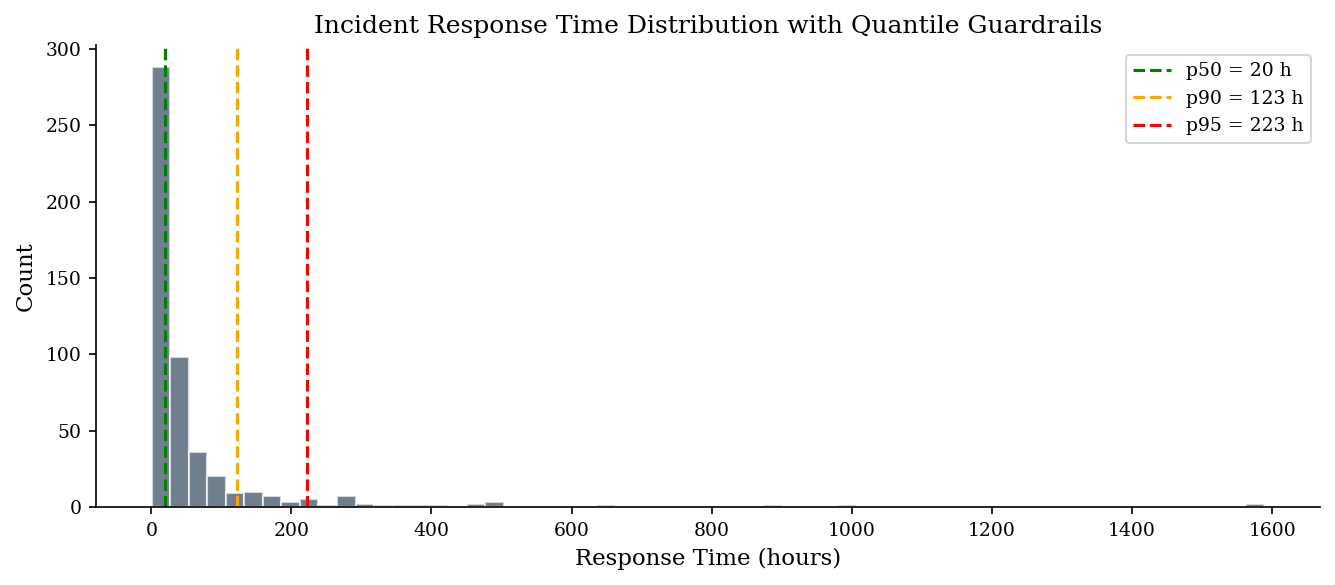

In [6]:
p50 = np.percentile(response_hours, 50)
p90 = np.percentile(response_hours, 90)
p95 = np.percentile(response_hours, 95)

print(f"p50 (median): {p50:.1f} hours")
print(f"p90:          {p90:.1f} hours")
print(f"p95:          {p95:.1f} hours")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(response_hours, bins=60, edgecolor="white", alpha=0.7, color=DARK_BG)

for pct, val, color in [("p50", p50, "green"), ("p90", p90, "orange"), ("p95", p95, "red")]:
    ax.axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{pct} = {val:.0f} h")

ax.set_xlabel("Response Time (hours)")
ax.set_ylabel("Count")
ax.set_title("Incident Response Time Distribution with Quantile Guardrails")
ax.legend()
plt.tight_layout()
plt.show()

## Rates and Proportions

Phishing click rates, patch compliance percentages, and detection rates are all proportions. A point estimate is not enough; you need a confidence interval, especially with small samples.

The naive confidence interval $\hat p \pm z \sqrt{\hat p(1-\hat p)/n}$ (Wald interval) fails badly when $\hat p$ is near 0 or 1 — exactly where security proportions tend to live. A campaign with 2 clicks out of 500 emails gives $\hat p = 0.004$; the Wald interval can go negative.

The **Wilson score interval** corrects this by adding pseudo-observations, producing valid intervals even at extreme proportions and small samples. Always use Wilson (or Agresti--Coull) for click rates, false-positive rates, and compliance percentages.

In [7]:
# Simulate 12 monthly phishing campaigns, each sent to 200 employees
clicks = sample('binomial', 12, n=200, p=0.08, rng=make_rng(42))
n_sent = 200

click_rates = clicks / n_sent
print("Monthly click counts:", clicks)
print("Click rates:         ", np.round(click_rates, 3))
print(f"Overall mean rate:    {np.mean(click_rates):.3f}")

Monthly click counts: [19 15 20 18 11 24 19 19 12 15 15 22]
Click rates:          [0.095 0.075 0.1   0.09  0.055 0.12  0.095 0.095 0.06  0.075 0.075 0.11 ]
Overall mean rate:    0.087


In [8]:
# Wilson confidence interval for the overall proportion
total_clicks = int(np.sum(clicks))
total_sent = n_sent * len(clicks)
p_hat = total_clicks / total_sent

z = scipy.stats.norm.ppf(0.975)  # 95% CI

denominator = 1 + z**2 / total_sent
centre = (p_hat + z**2 / (2 * total_sent)) / denominator
margin = (z / denominator) * np.sqrt(p_hat * (1 - p_hat) / total_sent + z**2 / (4 * total_sent**2))

wilson_lo = centre - margin
wilson_hi = centre + margin

print(f"Observed rate:    {p_hat:.4f}")
print(f"Wilson 95% CI:    [{wilson_lo:.4f}, {wilson_hi:.4f}]")
print(f"\nWe are 95% confident the true click rate is between {wilson_lo:.1%} and {wilson_hi:.1%}.")

Observed rate:    0.0871
Wilson 95% CI:    [0.0765, 0.0990]

We are 95% confident the true click rate is between 7.6% and 9.9%.


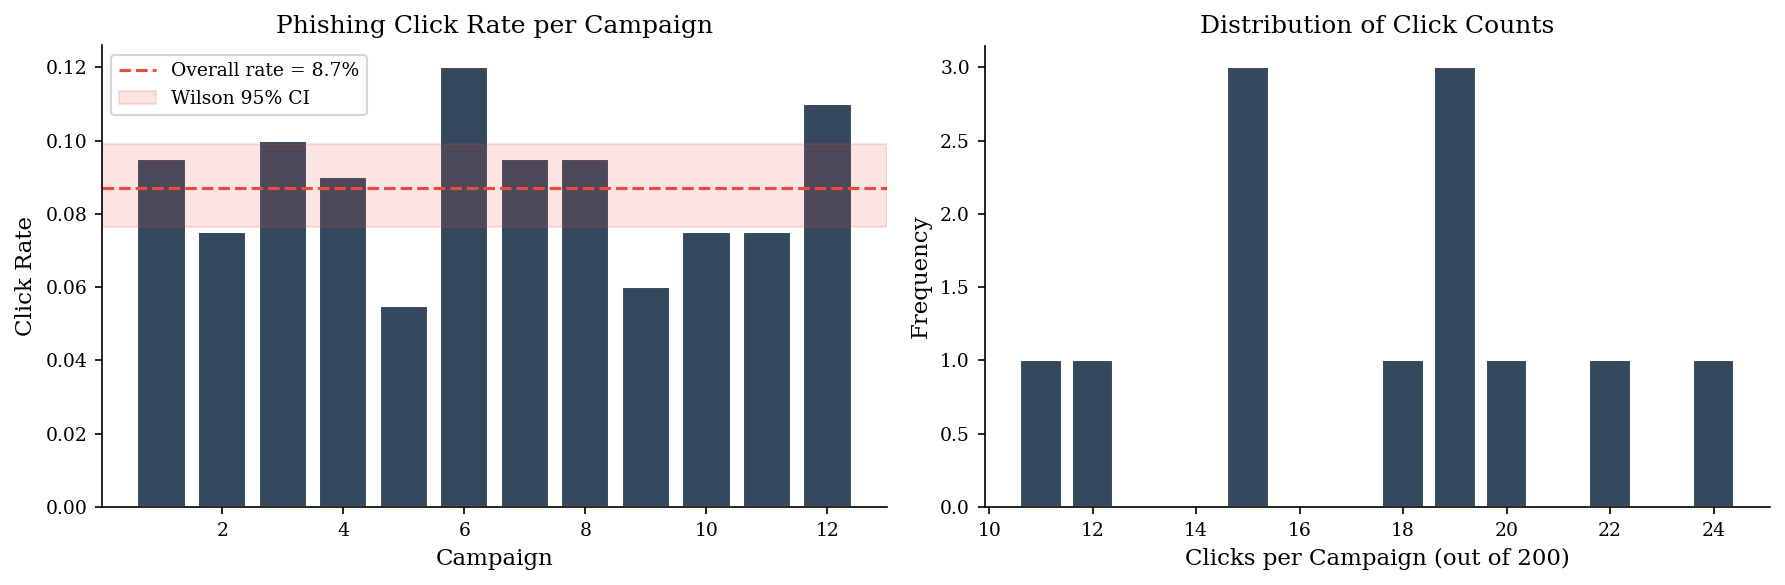

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: click rates per campaign with CI band
months = np.arange(1, len(click_rates) + 1)
axes[0].bar(months, click_rates, color=DARK_BG, edgecolor="white")
axes[0].axhline(p_hat, color=ACCENT, linestyle="--", linewidth=1.5, label=f"Overall rate = {p_hat:.1%}")
axes[0].axhspan(wilson_lo, wilson_hi, alpha=0.15, color=ACCENT, label=f"Wilson 95% CI")
axes[0].set_xlabel("Campaign")
axes[0].set_ylabel("Click Rate")
axes[0].set_title("Phishing Click Rate per Campaign")
axes[0].legend(fontsize=9)

# Right: distribution of click counts
vals, counts = np.unique(clicks, return_counts=True)
axes[1].bar(vals, counts, color=DARK_BG, edgecolor="white")
axes[1].set_xlabel("Clicks per Campaign (out of 200)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Click Counts")

plt.tight_layout()
plt.show()

## Poisson Counts

Security incidents per time period — alerts per shift, breaches per quarter, phishing campaigns per month — are counts. The Poisson distribution models these: events arrive independently at a constant average rate $\lambda$.

For count data — incidents per month, alerts per shift — the **Poisson confidence interval** applies. With $k$ observed events the exact interval uses the chi-squared distribution; for $k \geq 20$ the normal approximation $k \pm z\sqrt{k}$ is adequate. Report the rate with its CI so stakeholders see whether a month-over-month change is signal or noise.

The key insight: with count data, you get a confidence interval on the rate for free. If you observed 8 incidents this month, the 95% CI is roughly [3.5, 15.8]. So if next month shows 12, that's *within the noise band* — not necessarily a real increase. This prevents over-reaction to random fluctuations and helps separate signal from variance.

> **Note:** A SOC that observes 8 critical incidents in January and 12 in February might panic about a 50% increase. But the Poisson 95% CI for 8 events is roughly [3.5, 15.8] — February's 12 is well within the noise band. Confidence intervals prevent over-reaction to random fluctuations and help distinguish trends from variance.

Observed monthly incidents: [4 4 5 1 7 1 4 2 2 6 3 1 6 2 5 0 2 2 3 4 0 2 2 3]
Estimated rate (lambda):   2.96
95% CI:                    [2.27, 3.65]


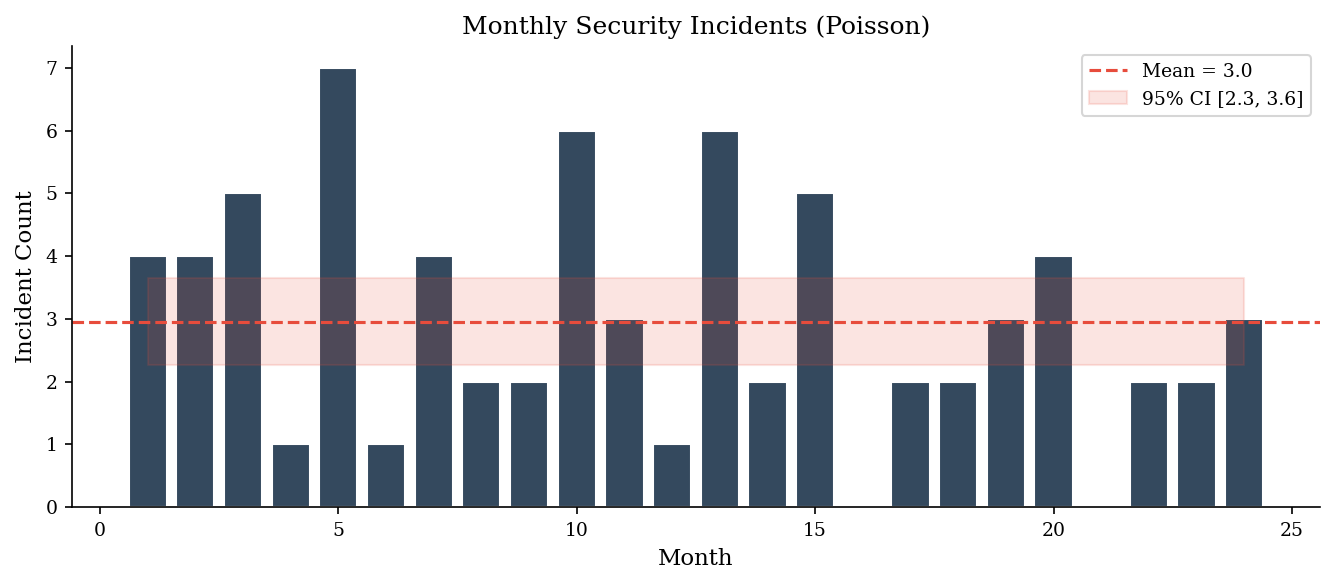

In [10]:
monthly_incidents = sample('poisson', 24, lam=3.2, rng=make_rng(42))

lambda_hat = np.mean(monthly_incidents)
n_months = len(monthly_incidents)

# CI for Poisson rate: lambda_hat +/- z * sqrt(lambda_hat / n)
z = scipy.stats.norm.ppf(0.975)
se = np.sqrt(lambda_hat / n_months)
ci_lo = lambda_hat - z * se
ci_hi = lambda_hat + z * se

print(f"Observed monthly incidents: {monthly_incidents}")
print(f"Estimated rate (lambda):   {lambda_hat:.2f}")
print(f"95% CI:                    [{ci_lo:.2f}, {ci_hi:.2f}]")

fig, ax = plt.subplots(figsize=(9, 4))
months = np.arange(1, n_months + 1)
ax.bar(months, monthly_incidents, color=DARK_BG, edgecolor="white")
ax.axhline(lambda_hat, color=ACCENT, linestyle="--", linewidth=1.5, label=f"Mean = {lambda_hat:.1f}")
ax.fill_between(months, ci_lo, ci_hi, alpha=0.15, color=ACCENT, label=f"95% CI [{ci_lo:.1f}, {ci_hi:.1f}]")
ax.set_xlabel("Month")
ax.set_ylabel("Incident Count")
ax.set_title("Monthly Security Incidents (Poisson)")
ax.legend()
plt.tight_layout()
plt.show()

## Five-Number Summary + p95

The five-number summary (min, Q25, median, Q75, max) plus the 95th percentile should be your default descriptive output for any security metric. It fits on one line and immediately reveals skew (is the median much closer to Q25 than Q75?), spread (how wide is the IQR?), and tail risk (how far is p95 from the median?).

Think of it as a one-line health check before you do any modeling.

In [11]:
def five_number_plus(data, label="value"):
    """Return a five-number summary plus p95."""
    keys = ["min", "Q1", "median", "Q3", "p95", "max"]
    vals = [
        np.min(data),
        np.percentile(data, 25),
        np.median(data),
        np.percentile(data, 75),
        np.percentile(data, 95),
        np.max(data),
    ]
    print(f"Five-number summary + p95 for {label}:")
    for k, v in zip(keys, vals):
        print(f"  {k:>6s}: {v:>10.1f}")
    return dict(zip(keys, vals))

_ = five_number_plus(response_hours, label="response time (hours)")

Five-number summary + p95 for response time (hours):
     min:        0.4
      Q1:        7.4
  median:       20.2
      Q3:       48.5
     p95:      223.0
     max:     1588.9


## Putting It Together: A Descriptive Workflow

When you encounter a new security dataset, follow this sequence:

1. Compute the five-number summary plus p95
2. Check the mean/median ratio to assess skew
3. Choose **median + IQR** or **mean + SD** based on skew
4. For proportions, compute Wilson CIs
5. For counts, compute Poisson CIs

This five-step routine takes under a minute and gives you a defensible, honest summary before any modeling begins.

The goal is not statistical elegance — it is avoiding the common failure mode where a single misleading number drives a bad decision. A well-chosen summary statistic paired with an appropriate uncertainty interval is worth more than a complex model built on a poorly understood dataset.

## Common Traps

**Heavy tails treated as normal.** If you compute "mean $\pm$ 2 SD" on breach-cost data and call it a 95% interval, you will systematically undercount large losses. Most security metrics (breach cost, dwell time, response time) are right-skewed. Test for skew first; if skewness > 1, use quantile-based summaries.

**Different denominators and Simpson's paradox.** Averaging click rates across campaigns of different sizes without weighting by campaign size produces a biased aggregate. But the problem goes deeper than weighting. A company-wide phishing click rate of 5% might decompose into 1% in engineering and 15% in sales. If engineering runs ten times more campaigns than sales, the aggregate looks reassuringly low — while the actual risk (in sales, where social engineering matters most) is hidden.

This is **Simpson's paradox**: an aggregate trend that reverses when you condition on a subgroup. It appears everywhere in security data. A MTTR that "improves" quarter-over-quarter might mask the fact that you're handling more easy tickets (password resets) and fewer hard ones (lateral movement investigations) — the mean dropped, but the hard tickets got slower. A vulnerability remediation rate that looks compliant at 90% might be 99% for low-severity CVEs and 40% for criticals. The aggregate passes audit; the reality is a time bomb.

The defense is simple: always ask "per what?" and segment before you summarize. If the metric changes direction when you split by department, severity, asset type, or time period, the aggregate is lying. Report the segments, not the average.

**Censoring bias.** If you measure MTTR only on *closed* tickets, you systematically exclude the long-running incidents still open — the ones that represent the greatest operational risk. This is **right-censoring**: you observe a lower bound on the true duration, not the duration itself. An incident that has been open for 45 days has a true resolution time of *at least* 45 days, but your ticketing system reports nothing because the clock is still running. If you drop these observations (common in dashboard queries that filter to "status = closed"), you are silently deleting the longest-duration incidents from your summary.

The problem compounds with observation windows. If your reporting period is 90 days, any incident that takes longer than 90 days to resolve is invisible in that quarter's metrics. The reported MTTR looks stable or improving, but only because the hard cases haven't closed yet. Next quarter, when they finally close, you get a sudden spike that looks like a regression — but was actually always there, just hidden by the censoring.

The correct treatment is survival analysis (covered in Part 4), which accounts for censored observations as lower bounds rather than discarding them. For quick descriptive work, report the count of open incidents alongside your MTTR and flag what fraction of the cohort is still unresolved. If 20% of incidents from this quarter are still open, your MTTR is unreliable — say so explicitly rather than presenting a precise-looking number.

**Seasonality and aggregation windows.** Weekly alert volumes may show strong day-of-week effects; monthly counts may exhibit end-of-quarter spikes (compliance scans, audit activity). Aggregating across these patterns without accounting for seasonality masks real structure and invites misleading trend claims. Always check for periodicity before computing summary statistics over time.

## Base-Rate Neglect: The Evidence is Stronger Than You Think

Small samples carry more information than intuition credits them for. In a classic demonstration, Raiffa (1968) presented subjects with 12 draws from a bag — 8 of one color, 4 of another — and asked them to estimate the probability that the bag was predominantly one color. Lawyers guessed 50--55%; statistics students guessed around 70%. The Bayesian answer is **96.7%**. The gap between gut estimate and computed posterior is the base-rate neglect tax.

In security, this shows up whenever small-sample evidence is dismissed as inconclusive. A threat-intelligence feed flags 8 of 12 indicators as malicious. An analyst, anchored on the overall false-positive rate, calls it noise. But even a modest cluster of confirmatory signals can shift the posterior dramatically. The failure is not in the evidence — it is in the mental model that requires overwhelming evidence before updating.

The antidote is not "trust small samples blindly" — it is "compute the posterior explicitly." When the prior is 50/50 and the evidence is 8-out-of-12, the posterior is 96.7%. When the prior is 1% (a genuinely rare event), the same evidence moves the posterior to about 20% — meaningful but not conclusive. The prior matters, and intuition usually gets the interaction between prior and evidence wrong. Bayes' rule gets it right.

Base-rate neglect works in both directions. When evidence *confirms* a rare event, people underweight it (the lawyers above). When a headline *names* a rare event, people overweight it (availability bias). The antidote in both cases is the same: compute the posterior, don't estimate it.

> *"Subjects vastly underestimate the power of a small sample."*
> — Howard Raiffa, *Decision Analysis* (1968)

In [12]:
# Raiffa's chip-bag problem: Bayesian posterior
# P(green bag | 8 green in 12 draws)
from scipy.stats import binom

prior_green = 0.5  # equal prior
p_green_if_green_bag = 0.7
p_green_if_white_bag = 0.3

# Likelihood of 8 green in 12 draws from each bag
lik_green_bag = binom.pmf(8, 12, p_green_if_green_bag)
lik_white_bag = binom.pmf(8, 12, p_green_if_white_bag)

# Bayes' theorem
posterior_green = (lik_green_bag * prior_green) / (
    lik_green_bag * prior_green + lik_white_bag * (1 - prior_green)
)

print(f"Prior P(green bag):     {prior_green:.1%}")
print(f"Evidence:               8 green out of 12 draws")
print(f"Posterior P(green bag): {posterior_green:.1%}")
print(f"\nThe lawyers guessed ~55%. The math says {posterior_green:.1%}.")
print("Small samples carry more information than intuition credits them for.")

Prior P(green bag):     50.0%
Evidence:               8 green out of 12 draws
Posterior P(green bag): 96.7%

The lawyers guessed ~55%. The math says 96.7%.
Small samples carry more information than intuition credits them for.
